In [31]:
import json
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

In [32]:
# Load group data from JSON file
with open('results/full_run_2/simulation_results_groups_1_10.json', 'r') as f:
    results_1_10 = json.load(f)

with open('results/full_run_2/simulation_results_groups_11_20.json', 'r') as f:
    results_11_20 = json.load(f)

with open('results/full_run_2/simulation_results_groups_21_30.json', 'r') as f:
    results_21_30 = json.load(f)

with open('results/full_run_2/simulation_results_groups_31_40.json', 'r') as f:
    results_31_40 = json.load(f)

results_1_10.update(results_11_20)
results_1_10.update(results_21_30)
results_1_10.update(results_31_40)
results = results_1_10

with open('simulation_resources/participant_attitudes.json', 'r') as f:
    participants = json.load(f)

groups = list(set([int(x.split("_")[1]) for x in results.keys()]))

In [33]:
df = []
for participant in participants:
    pid = participant['id']
    groupid = participant['group']
    if groupid in groups:
        for question in participant['questions'].keys():
            row = {}
            row['id'] = pid
            row["question"] = question
            row["before_attitude"] = participant['questions'][question]
            groupIndex = "Group_" + str(groupid) + "_" + question
            row["after_attitude"] = results[groupIndex]['rankings'][str(pid)]
            df.append(row)

df = pd.DataFrame(df)

In [34]:
question_df = pd.read_csv("clean_data/question_level_master_dataset.csv")
compare_df = df.merge(question_df, left_on=["id","question"], right_on=['ID',"Question"], how="left")
compare_df.drop(columns=["id","question","before_attitude","BeforeResponse","AfterResponse"], inplace=True)
compare_df.rename(columns={"after_attitude":"LLMNumber"}, inplace=True)

In [35]:
compare_df

,LLMNumber,ID,Question,QuestionText,Topic,ValidResponse,BeforeNumber,AfterNumber,GROUP,RACE,AGEBRACKET,EDUCATION,PARTYBEFORE,GENDER,AGE
0,6.0,0,Q1,How poorly or well would you say the system of...,Democracy,True,5,9,1,"White, non-Hispanic",18-29,Some college,Independent,Male,21
1,2.0,0,Q2A,[Reduce the number of refuges allowed to reset...,Immigration,True,0,2,1,"White, non-Hispanic",18-29,Some college,Independent,Male,21
2,10.0,0,Q2B,[Increase personnel to process asylum seekers'...,Immigration,True,10,10,1,"White, non-Hispanic",18-29,Some college,Independent,Male,21
3,0.0,0,Q2C,[Provide aid to reduce poverty and violence in...,Immigration,True,0,7,1,"White, non-Hispanic",18-29,Some college,Independent,Male,21
4,5.0,0,Q2D,[Increase the number of visas for skilled work...,Immigration,True,5,10,1,"White, non-Hispanic",18-29,Some college,Independent,Male,21
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
25099,6.0,522,Q6F,[The US should recommit to the Iran Nuclear Ag...,Global Position,True,5,5,6,"White, non-Hispanic",45-59,BA or above,Democrat,Female,45
25100,9.0,522,Q6G,[Presidents should be required to obtain expli...,Global Position,True,10,5,6,"White, non-Hispanic",45-59,BA or above,Democrat,Female,45
25101,10.0,522,Q6H,[The U.S. should intervene abroad when it is n...,Global Position,True,10,10,6,"White, non-Hispanic",45-59,BA or above,Democrat,Female,45
25102,4.0,522,Q6I,[The U.S. should increase military spending by...,Global Position,True,3,0,6,"White, non-Hispanic",45-59,BA or above,Democrat,Female,45


In [36]:
compare_df["ABS_DIFF"] = abs(compare_df["LLMNumber"] - compare_df["AfterNumber"])
compare_df["DIFF"] = (compare_df["LLMNumber"] - compare_df["AfterNumber"])

In [37]:
acceptable_range = list(range(0,11))

In [38]:
# filter out rows where LLMNumber, BeforeNumber, or AfterNumber is 77 98 or 99
compare_df = compare_df[compare_df["LLMNumber"].isin(acceptable_range)]
compare_df = compare_df[compare_df["AfterNumber"].isin(acceptable_range)]
compare_df = compare_df[compare_df["BeforeNumber"].isin(acceptable_range)]

In [39]:
compare_df.shape

(23094, 17)

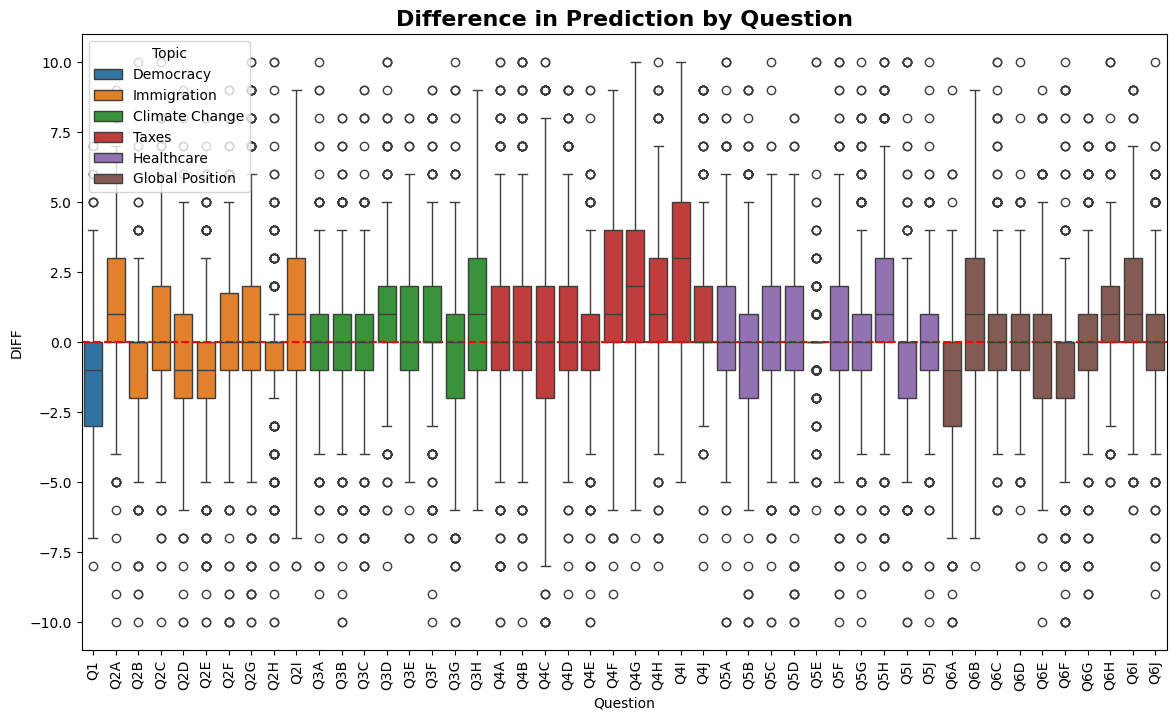

In [40]:
fig = plt.figure(figsize=(14, 8))
sns.boxplot(data=compare_df, x='Question', y='DIFF', hue='Topic')
plt.title('Difference in Prediction by Question', fontsize=16, fontweight='bold')
plt.xticks(rotation=90)
plt.axhline(0, color='red', linestyle='--')

/var/folders/qw/dj7vjbyd6kb8q83q6chjb9m00000gn/T/ipykernel_3050/588005056.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(


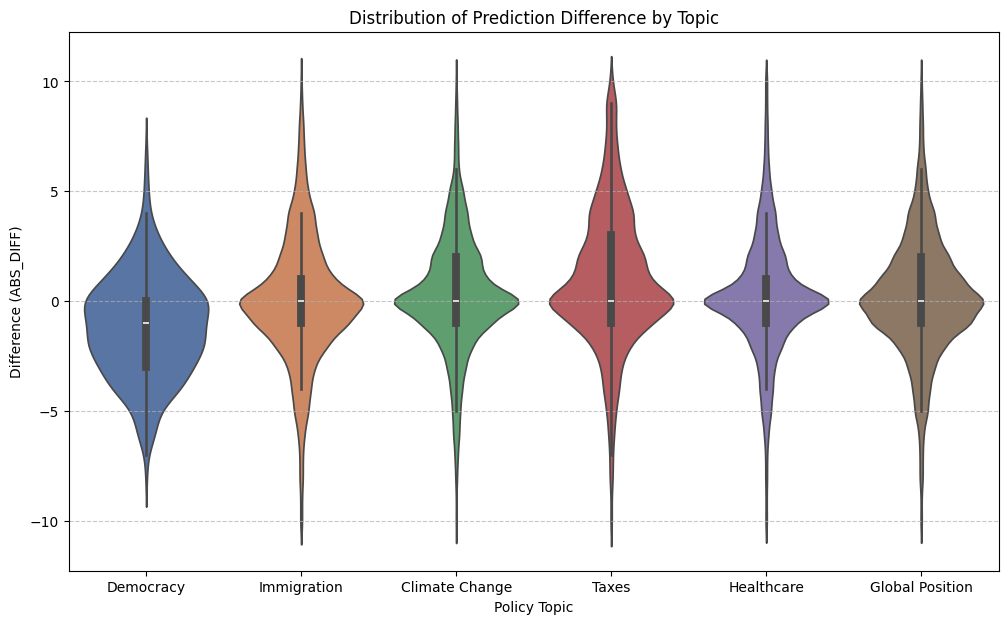

In [41]:
# Assuming your data is loaded into a Pandas DataFrame called 'df'
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 7))

# Create the Box Plot
sns.violinplot(
    x='Topic',         # Use Topic as the categorical axis
    y='DIFF',      # Use ABS_DIFF as the continuous distribution axis
    data=compare_df,
    palette='deep'     # Use a distinct color palette
)

plt.title('Distribution of Prediction Difference by Topic')
plt.xlabel('Policy Topic')
plt.ylabel('Difference (ABS_DIFF)')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

In [42]:
import pandas as pd
from scipy.stats import chi2_contingency

# Assume 'df' is your DataFrame
stats_df = []
for question in compare_df['Question'].unique():
    # Filter the data for a specific question
    row = {}
    question_data = compare_df[compare_df['Question'] == question]

    # ... proceed with the test on question_data ...

    # Create a contingency table
    contingency_table = pd.crosstab(question_data['LLMNumber'], question_data['AfterNumber'])

    # Perform the Chi-squared test
    chi2, p_value, dof, expected = chi2_contingency(contingency_table)

    # Interpret the result
    alpha = 0.05
    row['Question'] = question
    row['QuestionText'] = question_data['QuestionText'].iloc[0]
    row['p_value'] = p_value
    row['Chi2'] = chi2
    row['Degrees_of_Freedom'] = dof
    row['Expected_Frequencies'] = expected.tolist()
    
    if p_value < alpha:
        row['Significant'] = True
        #print("Same")
        #print("Result: Statistically significant relationship found. (Reject the null hypothesis of independence)")
    else:
        row['Significant'] = False
        #print("Different")
        #print("Result: No significant relationship found. (Fail to reject the null hypothesis of independence)")
    stats_df.append(row)
stats_df = pd.DataFrame(stats_df)

In [43]:
compare_df.columns

Index(['LLMNumber', 'ID', 'Question', 'QuestionText', 'Topic', 'ValidResponse',
       'BeforeNumber', 'AfterNumber', 'GROUP', 'RACE', 'AGEBRACKET',
       'EDUCATION', 'PARTYBEFORE', 'GENDER', 'AGE', 'ABS_DIFF', 'DIFF'],
      dtype='object')

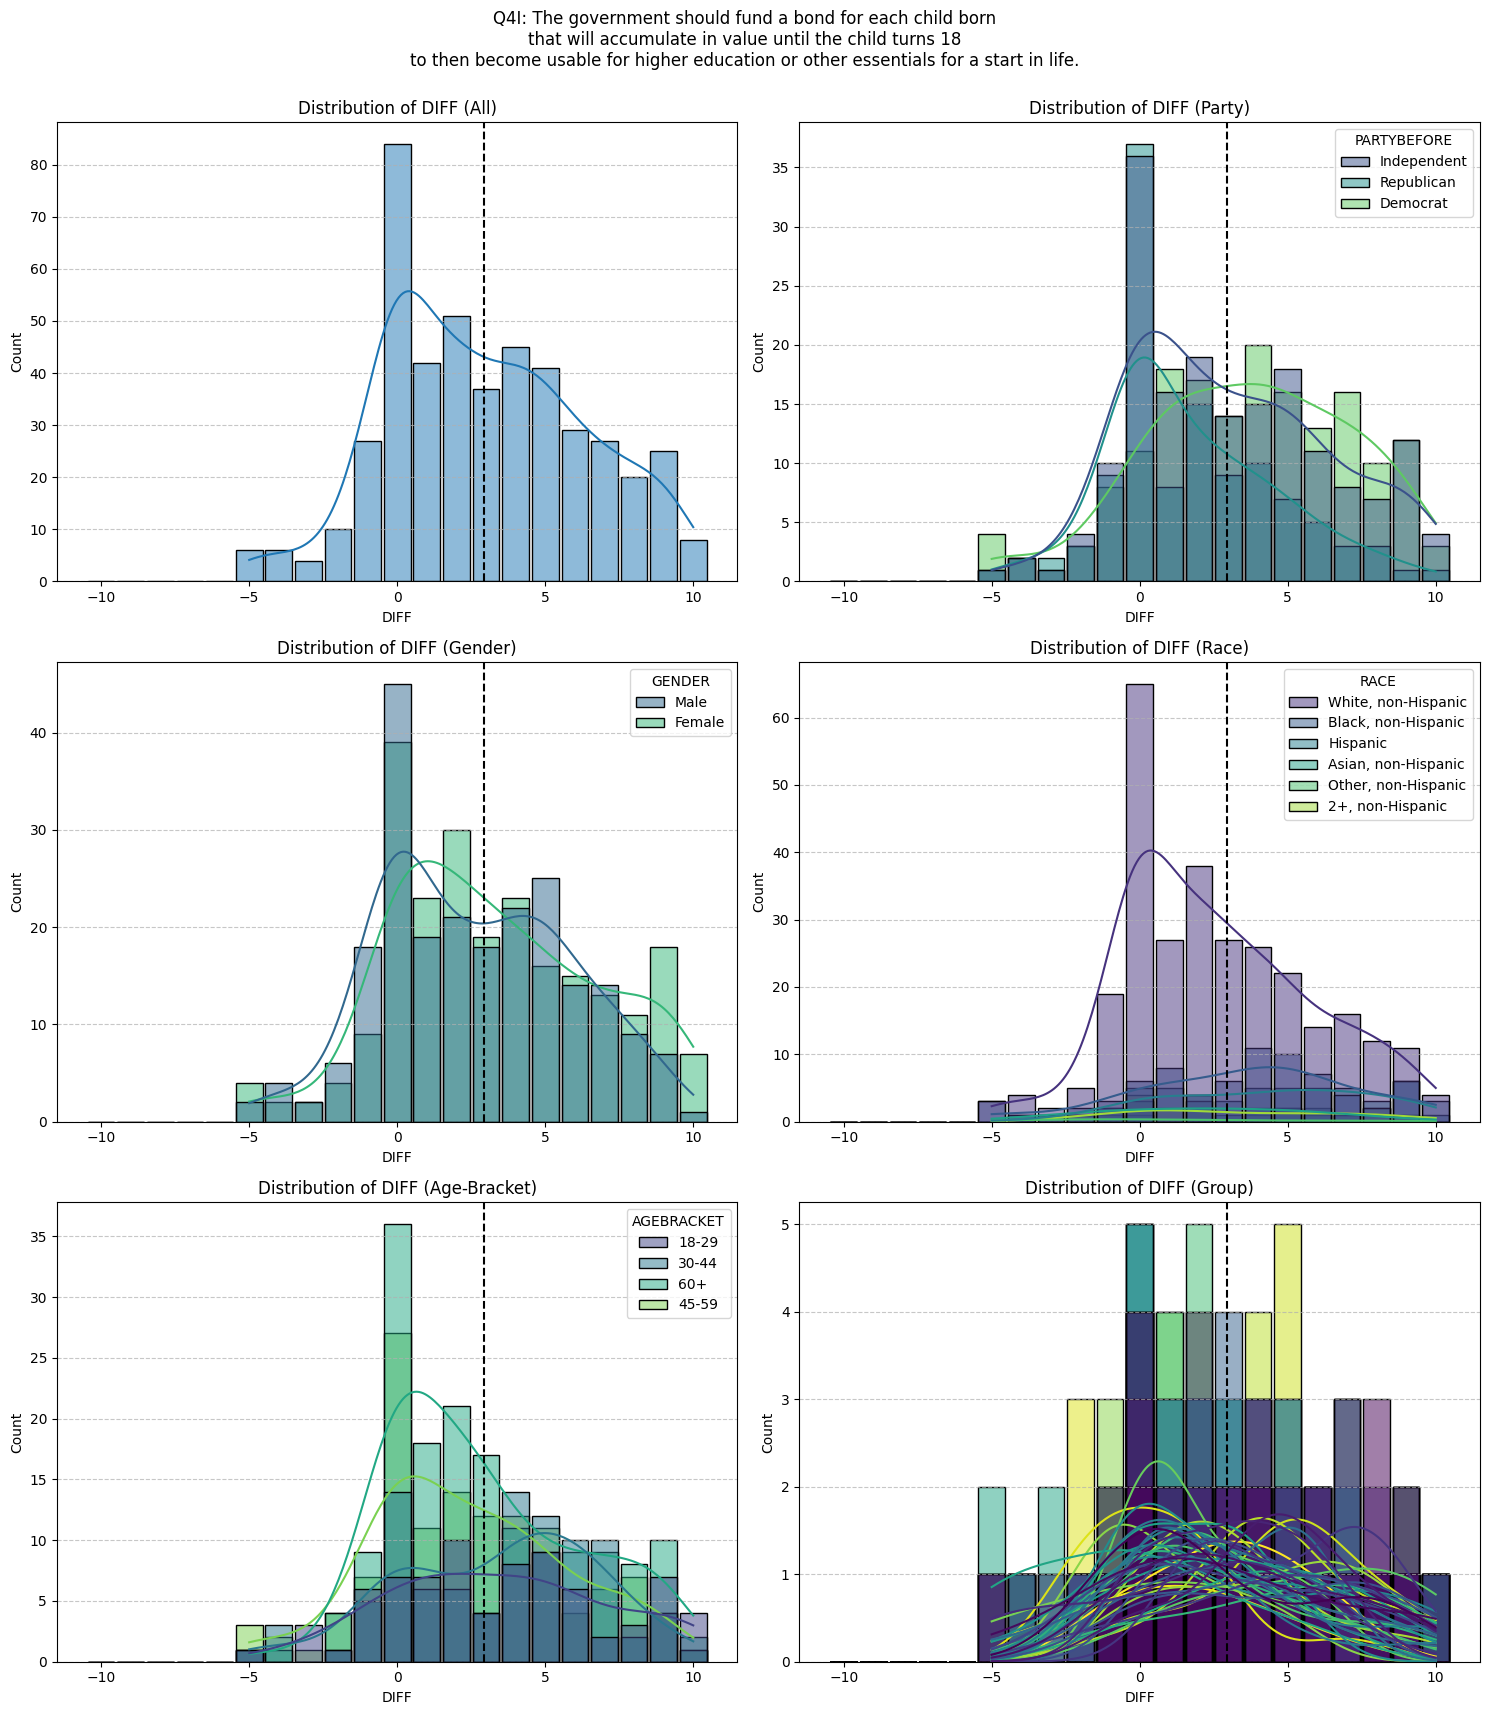

In [44]:
compare_df_Q = compare_df[compare_df["Question"] == "Q4I"]
# i want 6 plots for Q4I with different hues for demographics
fig, ax = plt.subplots(3, 2, figsize=(15, 18))

plot_dict = {"All" : (0,0), "Party" : (0,1), "Gender" : (1,0), "Race" : (1,1), "Age-Bracket" : (2,0), "Group" : (2,1)}
var_map = {"All" : "Ignore", "Party":"PARTYBEFORE", "Gender":"GENDER","Race":"RACE", "Age-Bracket":"AGEBRACKET", "Group":"GROUP"}
for plot_var, position in plot_dict.items():
    plt.sca(ax[position])
    if plot_var == "All":
        sns.histplot(data=compare_df_Q, x='DIFF', bins=bin_edges, kde=True , shrink=0.9)
        plt.title(f'Distribution of DIFF (All)')
    else:
        sns.histplot(data=compare_df_Q, x='DIFF', hue=var_map[plot_var], palette='viridis', bins=bin_edges, kde=True , shrink=0.9)
        plt.title(f'Distribution of DIFF ({plot_var})')
    plt.xlabel('DIFF')
    plt.ylabel('Count')
    plt.grid(axis='y', linestyle='--', alpha=0.7)
    # plot the mean as a black dashed line
    mean_diff = compare_df_Q['DIFF'].mean()
    plt.axvline(mean_diff, color='black', linestyle='--', label=f'Mean: {mean_diff:.2f}')
    # if we are plotting group, no legend
    if plot_var == "Group":
        plt.legend([],[], frameon=False)

fig.suptitle("Q4I: The government should fund a bond for each child born\nthat will accumulate in value until the child turns 18\nto then become usable for higher education or other essentials for a start in life.")
plt.tight_layout(rect=[0, 0.03, 1, 0.98])

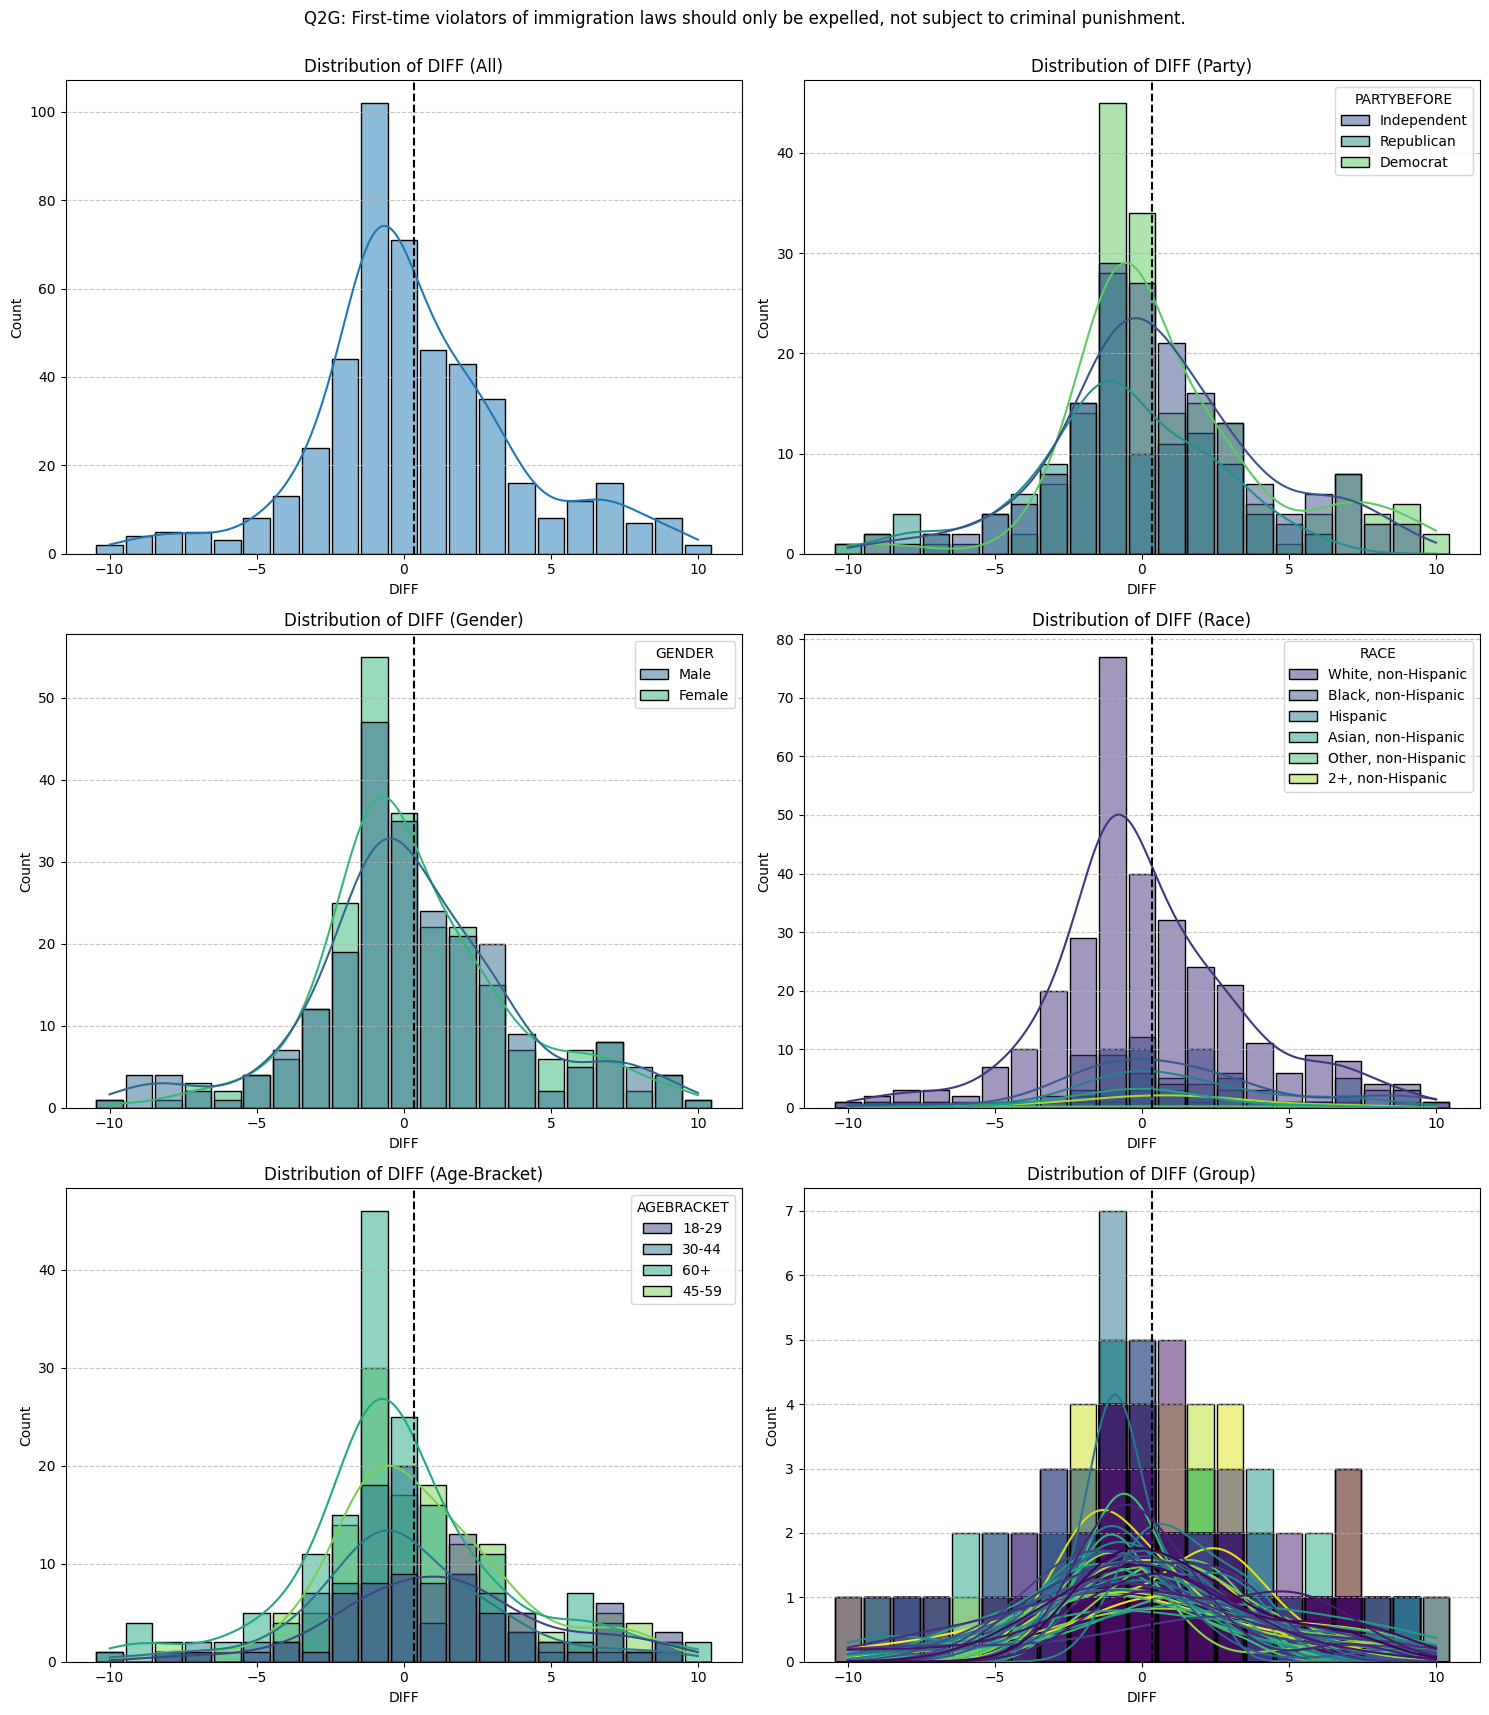

In [45]:
compare_df_Q = compare_df[compare_df["Question"] == "Q2G"]
# i want 6 plots for Q4I with different hues for demographics
fig, ax = plt.subplots(3, 2, figsize=(15, 18))

plot_dict = {"All" : (0,0), "Party" : (0,1), "Gender" : (1,0), "Race" : (1,1), "Age-Bracket" : (2,0), "Group" : (2,1)}
var_map = {"All" : "Ignore", "Party":"PARTYBEFORE", "Gender":"GENDER","Race":"RACE", "Age-Bracket":"AGEBRACKET", "Group":"GROUP"}
for plot_var, position in plot_dict.items():
    plt.sca(ax[position])
    if plot_var == "All":
        sns.histplot(data=compare_df_Q, x='DIFF', bins=bin_edges, kde=True , shrink=0.9)
        plt.title(f'Distribution of DIFF (All)')
    else:
        sns.histplot(data=compare_df_Q, x='DIFF', hue=var_map[plot_var], palette='viridis', bins=bin_edges, kde=True , shrink=0.9)
        plt.title(f'Distribution of DIFF ({plot_var})')
    plt.xlabel('DIFF')
    plt.ylabel('Count')
    plt.grid(axis='y', linestyle='--', alpha=0.7)
    
    # plot the mean as a black dashed line
    mean_diff = compare_df_Q['DIFF'].mean()
    plt.axvline(mean_diff, color='black', linestyle='--', label=f'Mean: {mean_diff:.2f}')
    # if we are plotting group, no legend
    if plot_var == "Group":
        plt.legend([],[], frameon=False)

fig.suptitle("Q2G: First-time violators of immigration laws should only be expelled, not subject to criminal punishment.")
plt.tight_layout(rect=[0, 0.03, 1, 0.98])

In [46]:
import pandas as pd
import numpy as np
from scipy import stats
import statsmodels.formula.api as smf
from sklearn.metrics import cohen_kappa_score

# df = pd.read_csv("your_data.csv") # Ensure data is loaded

results = []
questions = compare_df['Question'].unique()

for q in questions:
    # Subset data
    question_plot_df = compare_df[compare_df['Question'] == q]
    real_data = question_plot_df["AfterNumber"]
    sim_data = question_plot_df["LLMNumber"]

    # --- TEST 1: Paired Difference & Distribution ---
    try:
        # exact=False suppresses warnings for ties/zeros in large N
        w_stat, p_wilcox = stats.wilcoxon(real_data, sim_data)
    except ValueError:
        p_wilcox = 1.0

    try:
        kappa = cohen_kappa_score(real_data, sim_data, weights='quadratic')
    except:
        kappa = np.nan
        
    w_dist = stats.wasserstein_distance(real_data, sim_data)
    
    # Simple raw bias (Sim - Real)
    raw_bias = sim_data.mean() - real_data.mean()

    # --- TEST 2: Demographic Alignment (Regression) ---
    real_df = question_plot_df.copy().drop("LLMNumber", axis=1)
    real_df.rename(columns={"AfterNumber": "Response"}, inplace=True)
    real_df['Is_Simulated'] = 0
    
    sim_df = question_plot_df.copy().drop("AfterNumber", axis=1)
    sim_df.rename(columns={"LLMNumber": "Response"}, inplace=True)
    sim_df['Is_Simulated'] = 1
    
    question_regr_df = pd.concat([real_df, sim_df], ignore_index=True)
    
    # Base formula to check for systematic intercept shift (Bias)
    formula = "Response ~ C(RACE) + C(GENDER) + C(EDUCATION) + AGE + C(PARTYBEFORE) + Is_Simulated"

    formula1 = "Response ~ Is_Simulated * C(PARTYBEFORE)"
    
    try:
        model = smf.ols(formula, data=question_regr_df).fit(
            cov_type='cluster', 
            cov_kwds={'groups': question_regr_df['ID']}
        )
        sim_coef = model.params['Is_Simulated']
        sim_p_val = model.pvalues['Is_Simulated']
    except Exception as e:
        sim_coef, sim_p_val = np.nan, np.nan

    model1 = smf.ols(formula1, data=question_regr_df).fit(
        cov_type='cluster', 
        cov_kwds={'groups': question_regr_df['ID']}
    )
    
    results.append({
        'Question': q,
        'Raw_Bias': round(raw_bias, 3),        # Positive = LLM overestimates
        'Adj_Bias_Coef': round(sim_coef, 3),   # Bias after controlling for demographics
        'Bias_P_Value': round(sim_p_val, 3),   # Is the bias significant?
        'Wilcoxon_P': round(p_wilcox, 3),      # < 0.05 means distributions differ significantly
        'Weighted_Kappa': round(kappa, 3),          # Higher is better agreement
        'Wasserstein_Dist': round(w_dist, 3)   # Lower is better
    })

results_df = pd.DataFrame(results)
print(results_df.head())


  Question  Raw_Bias  Adj_Bias_Coef  Bias_P_Value  Wilcoxon_P  Weighted_Kappa  \
0       Q1    -1.145         -1.145         0.000       0.000           0.333   
1      Q2A     1.190          1.190         0.000       0.000           0.560   
2      Q2B    -0.703         -0.703         0.000       0.000           0.471   
3      Q2C     0.255          0.255         0.043       0.026           0.500   
4      Q2D    -0.698         -0.698         0.000       0.000           0.487   

   Wasserstein_Dist  
0             1.145  
1             1.313  
2             0.703  
3             0.457  
4             0.698  


In [64]:
results_df['is_significant'] = results_df.apply(lambda x : x['Bias_P_Value'] < 0.05, axis = 1)

([0,
  1,
  2,
  3,
  4,
  5,
  6,
  7,
  8,
  9,
  10,
  11,
  12,
  13,
  14,
  15,
  16,
  17,
  18,
  19,
  20,
  21,
  22,
  23,
  24,
  25,
  26,
  27,
  28,
  29,
  30,
  31,
  32,
  33,
  34,
  35,
  36,
  37,
  38,
  39,
  40,
  41,
  42,
  43,
  44,
  45,
  46,
  47],
 [Text(0, 0, 'Q1'),
  Text(1, 0, 'Q2A'),
  Text(2, 0, 'Q2B'),
  Text(3, 0, 'Q2C'),
  Text(4, 0, 'Q2D'),
  Text(5, 0, 'Q2E'),
  Text(6, 0, 'Q2F'),
  Text(7, 0, 'Q2G'),
  Text(8, 0, 'Q2H'),
  Text(9, 0, 'Q2I'),
  Text(10, 0, 'Q3A'),
  Text(11, 0, 'Q3B'),
  Text(12, 0, 'Q3C'),
  Text(13, 0, 'Q3D'),
  Text(14, 0, 'Q3E'),
  Text(15, 0, 'Q3F'),
  Text(16, 0, 'Q3G'),
  Text(17, 0, 'Q3H'),
  Text(18, 0, 'Q4A'),
  Text(19, 0, 'Q4B'),
  Text(20, 0, 'Q4C'),
  Text(21, 0, 'Q4D'),
  Text(22, 0, 'Q4E'),
  Text(23, 0, 'Q4F'),
  Text(24, 0, 'Q4G'),
  Text(25, 0, 'Q4H'),
  Text(26, 0, 'Q4I'),
  Text(27, 0, 'Q4J'),
  Text(28, 0, 'Q5A'),
  Text(29, 0, 'Q5B'),
  Text(30, 0, 'Q5C'),
  Text(31, 0, 'Q5D'),
  Text(32, 0, 'Q5E'),
  Text

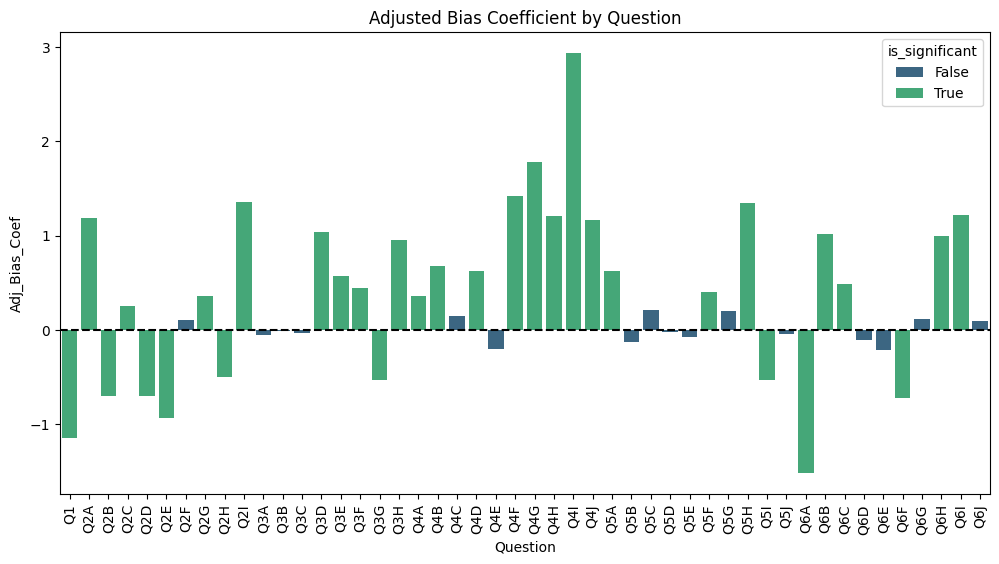

In [65]:
# plot adjusted bias results across questions
plt.figure(figsize=(12, 6))
sns.barplot(data=results_df, x='Question', y='Adj_Bias_Coef', hue='is_significant', palette='viridis', dodge=False)
plt.axhline(0, color='black', linestyle='--')
plt.title('Adjusted Bias Coefficient by Question')
plt.xlabel('Question')
#rotate x labels
plt.xticks(rotation=90)

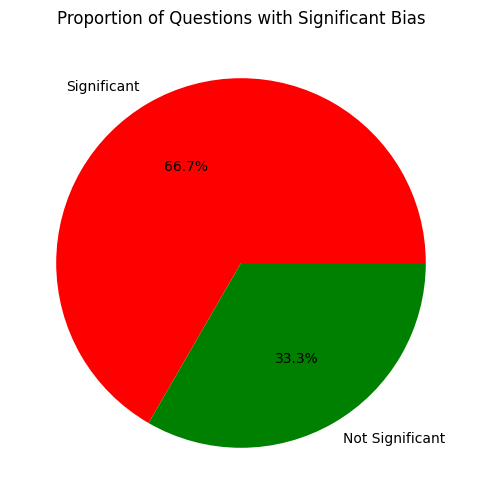

In [69]:
# pie plor of significant vs non significant
significant_counts = results_df['is_significant'].value_counts()    
plt.figure(figsize=(6, 6))
plt.pie(significant_counts, labels=['Significant', 'Not Significant'], autopct='%1.1f%%', colors=['red', 'green'])
plt.title('Proportion of Questions with Significant Bias')
plt.show()

In [48]:
model.params

Intercept                                    8.271324
C(RACE)[T.Asian, non-Hispanic]              -0.233364
C(RACE)[T.Black, non-Hispanic]              -0.418844
C(RACE)[T.Hispanic]                         -0.424967
C(RACE)[T.Other, non-Hispanic]              -0.955647
C(RACE)[T.White, non-Hispanic]              -0.078918
C(GENDER)[T.Male]                            0.022736
C(EDUCATION)[T.HS graduate or equivalent]   -0.355163
C(EDUCATION)[T.No HS diploma]               -0.925695
C(EDUCATION)[T.Some college]                -0.668724
C(PARTYBEFORE)[T.Independent]               -1.425143
C(PARTYBEFORE)[T.Republican]                -1.969004
AGE                                          0.006739
Is_Simulated                                 0.093117
dtype: float64

In [49]:
model1.params

Intercept                                     7.934066
C(PARTYBEFORE)[T.Independent]                -1.181378
C(PARTYBEFORE)[T.Republican]                 -1.481685
Is_Simulated                                  0.379121
Is_Simulated:C(PARTYBEFORE)[T.Independent]   -0.255465
Is_Simulated:C(PARTYBEFORE)[T.Republican]    -0.744200
dtype: float64

In [50]:
from statsmodels.miscmodels.ordinal_model import OrderedModel

question_regr_df = question_regr_df.copy()
question_regr_df['Response'] = question_regr_df['Response'].astype(int)
question_regr_df['AGE'] = question_regr_df['AGE'].astype(int)
question_regr_df['Is_Simulated'] = question_regr_df['Is_Simulated'].astype(int)

# Clean categorical vars
cats = ['RACE', 'GENDER', 'EDUCATION', 'PARTYBEFORE']
for col in cats:
    question_regr_df[col] = question_regr_df[col].astype(str).str.strip()

# Dummy encode
X_base = pd.get_dummies(question_regr_df[cats], drop_first=True)

# Add numeric vars
X_base['AGE'] = question_regr_df['AGE']
X_base['Is_Simulated'] = question_regr_df['Is_Simulated']

# Force numeric
X_base = X_base.apply(pd.to_numeric, errors='raise')

# Convert bools to integers
bool_cols = X_base.select_dtypes(include=['bool']).columns
X_base[bool_cols] = X_base[bool_cols].astype(int)

# Convert everything to float so statsmodels is happy
X_base = X_base.astype(float)


# Build model
y = question_regr_df['Response']

mod = OrderedModel(
    y,
    X_base,
    distr='logit'
)
res = mod.fit(method='bfgs', disp=False)

sim_coef = res.params['Is_Simulated']


In [51]:
res.summary()


<class 'statsmodels.iolib.summary.Summary'>
"""
                             OrderedModel Results                             
==============================================================================
Dep. Variable:               Response   Log-Likelihood:                -2017.1
Model:                   OrderedModel   AIC:                             4080.
Method:            Maximum Likelihood   BIC:                             4193.
Date:                Thu, 04 Dec 2025                                         
Time:                        14:42:49                                         
No. Observations:                 988                                         
Df Residuals:                     965                                         
Df Model:                          13                                         
=======================================================================================================
                                          coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------------------------------
RACE_Asian, non-Hispanic               -0.0725      0.394     -0.184      0.854      -0.845       0.700
RACE_Black, non-Hispanic               -0.2809      0.338     -0.831      0.406      -0.944       0.382
RACE_Hispanic                          -0.4084      0.352     -1.160      0.246      -1.098       0.282
RACE_Other, non-Hispanic               -1.2772      0.872     -1.465      0.143      -2.986       0.431
RACE_White, non-Hispanic               -0.0939      0.312     -0.301      0.764      -0.705       0.518
GENDER_Male                             0.0897      0.116      0.771      0.441      -0.138       0.318
EDUCATION_HS graduate or equivalent    -0.3019      0.214     -1.412      0.158      -0.721       0.117
EDUCATION_No HS diploma                -0.8541      0.503     -1.699      0.089      -1.839       0.131
EDUCATION_Some college                 -0.5174      0.124     -4.184      0.000      -0.760      -0.275
PARTYBEFORE_Independent                -1.1683      0.141     -8.286      0.000      -1.445      -0.892
PARTYBEFORE_Republican                 -1.5762      0.162     -9.713      0.000      -1.894      -1.258
AGE                                     0.0077      0.004      2.148      0.032       0.001       0.015
Is_Simulated                            0.0129      0.112      0.115      0.908      -0.207       0.233
0/1                                    -5.4098      0.467    -11.576      0.000      -6.326      -4.494
1/2                                    -0.2868      0.282     -1.018      0.308      -0.839       0.265
2/3                                    -0.1644      0.181     -0.906      0.365      -0.520       0.191
3/4                                    -1.0958      0.222     -4.942      0.000      -1.530      -0.661
4/5                                    -0.3759      0.125     -3.002      0.003      -0.621      -0.130
5/6                                    -0.2437      0.091     -2.678      0.007      -0.422      -0.065
6/7                                    -0.5183      0.090     -5.779      0.000      -0.694      -0.343
7/8                                    -0.5670      0.086     -6.585      0.000      -0.736      -0.398
8/9                                    -0.2917      0.074     -3.929      0.000      -0.437      -0.146
9/10                                   -0.2620      0.080     -3.263      0.001      -0.419      -0.105
=======================================================================================================
"""

In [52]:
pred_real = res.model.predict(res.params, X_base.assign(Is_Simulated=0))
pred_sim = res.model.predict(res.params, X_base.assign(Is_Simulated=1))


In [53]:
from scipy.stats import ks_2samp, chisquare

ks_2samp(real_data, sim_data)


KstestResult(statistic=np.float64(0.08704453441295547), pvalue=np.float64(0.04732479136771068), statistic_location=np.float64(9.0), statistic_sign=np.int8(-1))

In [54]:
from sklearn.metrics import cohen_kappa_score
cohen_kappa_score(real_data, sim_data, weights='quadratic')

0.4294041913282338

In [55]:
np.corrcoef(real_data, sim_data)[0,1]

np.float64(0.4309604684389054)